![Architecture of LeNet-5](figures/LeNet-5_Figure.png "LeNet-5")

### Environment Setup

In [165]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import random

### Data Loading & Normalization

In [114]:
def load_dataset(root='../cnn_scratch_nieNazwa/data', transform=transforms.ToTensor()):
    train_set = torchvision.datasets.CIFAR10(root=root, train=True, transform=transform, download=True)
    val_set = torchvision.datasets.CIFAR10(root=root, train=False, transform=transform, download=True)
    return train_set, val_set

In [144]:
train_data, val_data = load_dataset()

In [102]:
len(train_data), len(train_data[0]), train_data[0][0].shape

(50000, 2, torch.Size([3, 32, 32]))

In [103]:
len(val_data), len(val_data[0]), val_data[0][0].shape

(10000, 2, torch.Size([3, 32, 32]))

In [142]:
def Stats_PerChannel(data, get=False):
    imgs = torch.stack([img for img, _ in data])
    
    min_vals = imgs.amin(dim=(0, 2, 3))
    max_vals = imgs.amax(dim=(0, 2, 3))
    print(f"Min vals: {min_vals}\tMax vals: {max_vals}\n")
    
    means = torch.mean(imgs, dim=(0, 2, 3))
    stds = torch.std(imgs, dim=(0, 2, 3))
    print(f"Mean: {means}\tStd: {stds}")

    if get:
        m = tuple(round(x, 5) for x in means.tolist())
        s = tuple(round(x, 5) for x in stds.tolist())
        return m, s

In [145]:
norm_mean, norm_std = Stats_PerChannel(train_data, get=True)

Min vals: tensor([0., 0., 0.])	Max vals: tensor([1., 1., 1.])

Mean: tensor([0.4914, 0.4822, 0.4465])	Std: tensor([0.2470, 0.2435, 0.2616])


In [146]:
norm_mean, norm_std

((0.4914, 0.48216, 0.44653), (0.24703, 0.24349, 0.26159))

In [147]:
train_data, val_data = load_dataset(transform=transforms.Compose([transforms.ToTensor(),
     transforms.Normalize(norm_mean, norm_std)]))

In [148]:
Stats_PerChannel(train_data)

Min vals: tensor([-1.9892, -1.9802, -1.7070])	Max vals: tensor([2.0589, 2.1267, 2.1158])

Mean: tensor([-1.2720e-06, -6.4988e-06,  3.4809e-06])	Std: tensor([1.0000, 1.0000, 1.0000])


In [149]:
torch.tensor(norm_mean)

tensor([0.4914, 0.4822, 0.4465])

### Visualizing the dataset

In [159]:
classes = {0: 'plane', 1: 'car', 2: 'bird', 3: 'cat', 4: 'deer', 
           5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

In [183]:
def imshow(img, lbl, m, s):
    mean, std = torch.tensor(m), torch.tensor(s)
    
    img = img * std[:, None, None] + mean[:, None, None]   
    img.clamp_(0, 1)
    
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(lbl)

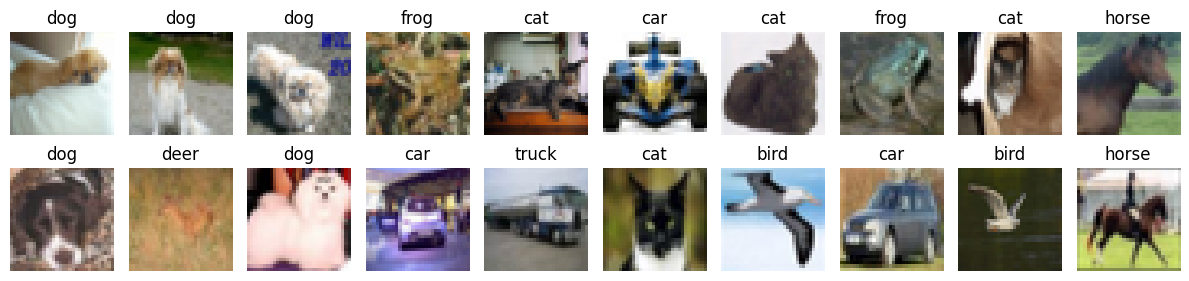

In [184]:
rand_idx = random.sample(range(0, len(train_data)), 20)

figure = plt.figure(figsize=(12, 3), tight_layout=True)

for i, idx  in enumerate(rand_idx):
    img, label = train_data[idx]
    figure.add_subplot(2, 10, i+1)
    imshow(img, classes[label], norm_mean, norm_std)
plt.show()

## Architecture

<center>
  <img src="figures/LeNet-5_Figure.png" width="750">
</center>

### Cross-Coorelation

#### Since LeNet does not implement padding and stride above 1 in any convolutional layer we may calculate output shape by simple formula:
- #### Number of Filters, (Input_height - Kernel_height + 1), (Input_width - Kernel_width + 1) - do poprawy

## Pack That shit in The class !!!!!

### I didn't want to just call nn.Conv2d() and treat it like a black box. This is my "from-scratch" implementation of the LeNet-5 architecture, focusing on the actual tensor logic behind convolutional layers.
#### This is my understanding and method

In [259]:
def cross_coor2d(X, K):
    X_h, X_w = X.shape[0], X.shape[1]
    K_h, K_w = K.shape[0], K.shape[1]
    Y = torch.zeros(X_h - K_h + 1, X_w - K_w + 1)
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+K_h, j:j+K_w]*K).sum()
    return Y

In [276]:
def coor2(X, K):
    return torch.stack([cross_coor2d(x, k) for x, k in zip(X, K)]).sum(dim=0)        

In [302]:
def calc_output(X, K, b):
    return torch.stack([coor2(X, k) for k in K]) + b

In [296]:
X_test.shape, K_test.shape, b_test.shape

(torch.Size([3, 32, 32]), torch.Size([6, 3, 5, 5]), torch.Size([6, 1, 1]))

In [303]:
calc_output(X_test, K_test, b_test).shape

torch.Size([6, 28, 28])

In [264]:
X_test = train_data[0][0]
X_test.shape

torch.Size([3, 32, 32])

In [295]:
b_test = torch.ones(6, 1, 1)
b_test

tensor([[[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]]])

In [293]:
test_do_b = torch.stack([torch.zeros(6, 6), torch.zeros(6, 6), torch.zeros(6, 6)])
test_do_b, test_do_b.shape

(tensor([[[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],
 
         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]],
 
         [[0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0.]]]),
 torch.Size([3, 6, 6]))

In [294]:
test_do_b + b_test

tensor([[[1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.]],

        [[1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.]],

        [[1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.]]])

In [265]:
K_test = torch.randn(6, 3, 5, 5)
K_test

tensor([[[[ 1.1521e+00,  2.7003e+00,  7.5162e-01, -2.9341e-01,  2.6861e-01],
          [-2.2335e-01, -7.7994e-01, -2.7740e-01,  1.9636e+00, -1.2298e+00],
          [-1.8790e-01, -7.8890e-01,  5.3603e-01, -1.2503e+00, -1.1338e+00],
          [ 8.4783e-02,  2.3424e+00,  2.6828e-01,  2.7710e-01,  1.8948e+00],
          [ 8.7758e-01, -1.8928e-01, -1.4492e+00,  6.4820e-01, -1.8806e-01]],

         [[-3.2534e-01, -5.8528e-01, -6.1142e-01,  2.8566e-01,  3.7306e-03],
          [-3.5201e-01,  1.2872e-01,  1.5177e+00, -5.4513e-01,  2.8992e-01],
          [-4.9354e-01,  1.3183e+00,  6.6803e-01, -1.9638e-01, -2.8307e-01],
          [-1.3115e-01, -1.3468e+00,  8.4164e-01,  2.6792e-01, -8.5885e-01],
          [-9.7987e-01,  4.1432e-02, -1.0506e+00, -2.3796e-01,  9.4929e-01]],

         [[-1.5963e+00,  9.8550e-01, -1.0533e+00,  2.4884e-03, -3.0721e-01],
          [-1.4851e+00,  8.4619e-02, -1.7399e-01, -9.9037e-01,  9.8255e-01],
          [ 1.3979e+00,  8.6504e-01, -9.9754e-01,  1.0713e+00,  5.4400e-

In [194]:
torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

tensor([[[0., 1.],
         [2., 3.]],

        [[1., 2.],
         [3., 4.]]])